# 라이브러리 세팅

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import RandomOverSampler  # 임포트 추가
from imblearn.over_sampling import SMOTE
import seaborn as sns

# 데이터 로드, csv파일 호출 명령어에서 csv 파일명이 바뀌었습니다. 이에 맞춰 clustered_data2 파일을 다운받으셔야합니다.

In [25]:
df = pd.read_csv("clustered_data2.csv")

features = [
    'activity_score', 'activity_steps', 'activity_inactive', 'activity_high',
    'activity_score_meet_daily_targets', 'activity_score_move_every_hour',
    'activity_daily_movement', 'activity_total'
]
X = df[features].values.astype(np.float32)
y = df['risk_level'].values.astype(np.int64)

In [26]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# 데이터 분할

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, stratify=y_train, random_state=42)

# Tensor 변환 및 DataLoader 생성

In [28]:
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
val_dataset = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

# MLP 모델 정의

In [29]:
class RiskClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
            )
    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RiskClassifier().to(device)

# 클래스 가중치 계산
class_weights = torch.tensor([1 / np.sum(y_resampled == i) for i in np.unique(y_resampled)], dtype=torch.float32).to(device)
print("Class Weights:", class_weights)
# CrossEntropyLoss에 가중치 적용
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 학습 루프
epochs = 70
train_loss_history, val_loss_history = [], []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_val_batch, y_val_batch in val_loader:
            X_val_batch, y_val_batch = X_val_batch.to(device), y_val_batch.to(device)
            val_outputs = model(X_val_batch)
            val_loss += criterion(val_outputs, y_val_batch).item()

    avg_train_loss = epoch_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    train_loss_history.append(avg_train_loss)
    val_loss_history.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

Class Weights: tensor([0.0002, 0.0002, 0.0002, 0.0002])
Epoch 1/70 | Train Loss: 0.6987 | Val Loss: 0.4403
Epoch 2/70 | Train Loss: 0.4761 | Val Loss: 0.3711
Epoch 3/70 | Train Loss: 0.4417 | Val Loss: 0.3500
Epoch 4/70 | Train Loss: 0.4076 | Val Loss: 0.3123
Epoch 5/70 | Train Loss: 0.3775 | Val Loss: 0.3050
Epoch 6/70 | Train Loss: 0.3653 | Val Loss: 0.2882
Epoch 7/70 | Train Loss: 0.3448 | Val Loss: 0.2761
Epoch 8/70 | Train Loss: 0.3271 | Val Loss: 0.2760
Epoch 9/70 | Train Loss: 0.3114 | Val Loss: 0.2419
Epoch 10/70 | Train Loss: 0.3010 | Val Loss: 0.2533
Epoch 11/70 | Train Loss: 0.2954 | Val Loss: 0.2323
Epoch 12/70 | Train Loss: 0.2886 | Val Loss: 0.2306
Epoch 13/70 | Train Loss: 0.2794 | Val Loss: 0.2160
Epoch 14/70 | Train Loss: 0.2711 | Val Loss: 0.2024
Epoch 15/70 | Train Loss: 0.2652 | Val Loss: 0.2096
Epoch 16/70 | Train Loss: 0.2629 | Val Loss: 0.2066
Epoch 17/70 | Train Loss: 0.2584 | Val Loss: 0.1988
Epoch 18/70 | Train Loss: 0.2442 | Val Loss: 0.1949
Epoch 19/70 | Tra

# Loss 그래프

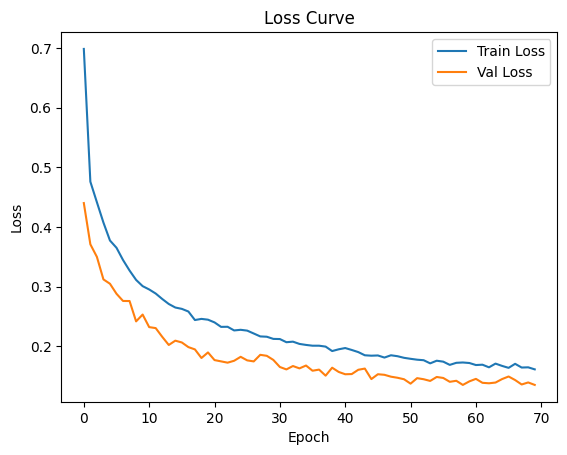

In [30]:
plt.plot(train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# 테스트 평가

Classification Report:
              precision    recall  f1-score   support

           0     0.9974    1.0000    0.9987      1150
           1     0.9464    0.9217    0.9339      1149
           2     0.9106    0.8852    0.8977      1150
           3     0.9388    0.9870    0.9623      1150

    accuracy                         0.9485      4599
   macro avg     0.9483    0.9485    0.9481      4599
weighted avg     0.9483    0.9485    0.9481      4599



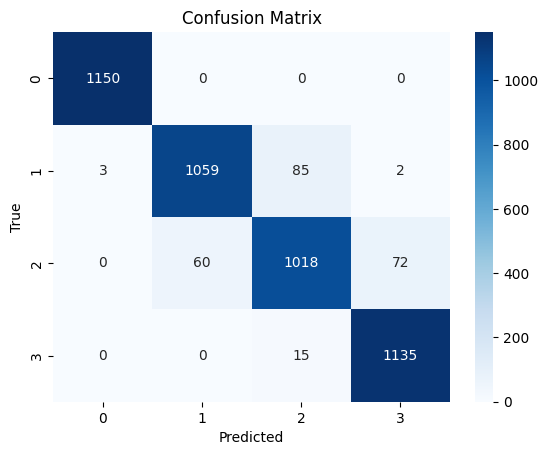

In [31]:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

print("Classification Report:")
print(classification_report(all_labels, all_preds, digits=4))

# Confusion Matrix 시각화
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()